# Recap


In [7]:
import numpy as np
import matplotlib.pyplot as plt

## Recap en uitbreiding

Je hebt al gezien hoe je een botsend deeltjesmodel maakt. Je startte toen met 1 of 2 deeltjes en hebt dit uitgebreid naar ~100 deeltjes. Daarbij was het logisch om gebruik te maken van classes.

Voor het maken van een simulatie van gasmoleculen in een gesloten volume zal je logischerwijs de volgende stappen doorlopen:
1. bepalen van initiële condities
2. definiëren van de deeltjes
3. definiëren van volume met randvoorwaarden
4. simulaties bestaande uit:
    - bepaling van positie van deeltjes
    - controleren op onderlinge botsingen 
    - controleren op botsingen met wanden
    - aanpassen van eigenschappen zoals totaal volume of temperatuur
    - opslaan van gegevens
    
```{note}
Alhoewel het interessant is om steeds een animatie te maken van de beweging van de deeltjes, vraagt dit veel rekentijd. Je kan ook regelmatig een plot maken om te controleren of het programma werkt zoals je verwacht.
```

### De initiële condities

In onze simulatie gaan we uit van een aantal aannames. Bij deze aannames wil je dat de simulatie een voorspellende waarde heeft voor een reëel systeem, maar ook dat de benodigde rekenkracht voor het uitvoeren van de simulatie op te brengen is. We kiezen daarom voor de volgende condities:

- Ons model heeft een beperkt en constant aantal deeltjes.
- We maken gebruik van een 2D simulatie.
- De deeltjes voelen geen onderlinge kracht en ondergaan alleen elastische botsingen.
- (tijdens simuleren) De tijdstap is voldoende klein. (d.w.z. de afgelegde weg $v_0*dt$ is klein in vergelijking met de diameter van de deeltjes, zodat we geen botsingen missen)

Hieronder geven we een aantal constanten voor onze code. Om de simulatie straks te kunnen interpreteren, vergelijken we deze eerst met een realistische situatie:

```{exercise} Lucht in een fietsband
:label: ex-recap-1

Als model gaan we uit van een deel van het volume van een fietsband die onder een druk van 10 bar staat. Schat hiervoor het gemiddelde volume $V_{molecuul}$. Het antwoord gebruik je zo direct in de code hieronder. 
```

```{solution} ex-recap-1
Jouw antwoord
```

De simulatie die we gaan maken bevat maar twee dimensies. We kunnen het oppervlak per deeltje in deze simulatie daarom kiezen als het zojuist berekende $V_{molecuul}^{2/3}$.

Voor de gemiddelde snelheid, $v$, van een molecuul geldt dat

$$
    \frac{1}{2}m\left< v^2\right> = \frac{f}{2} k_B T.
$$

Hierbij is $m$ de massa van het deeltje, $f$ het aantal dimensies, $k_B$ de constante van Boltzmann en $T$ de temperatuur.

```{exercise} Snelheid van een gasmolecuul
:label: ex-recap-2
Schat de snelheid van een gasmolecuul bij kamertemperatuur in twee dimensies. Ook deze heb je hierna nodig.
```

```{solution} ex-recap-2
Jouw antwoord
```

```{exercise} Radius
:label: ex-recap-3
Kies de eenheden waarin je de simulatie wilt gaan uitwerken. Dit kan in $\mathrm{m}$ maar ook in $\mathrm{mm}$ of iets anders. Pas de waardes voor de constanten `BOX_SIZE_0` en `V_0` in de hieronder gegeven code aan, zodat de simulatie een redelijk tweedimensionaal model is voor de fietsband. Hou hierbij het aantal deeltjes $N=40$ om de rekentijd van het model te beperken. Kies `RADIUS` gelijk aan 0.3 nm gebruik makend van jouw eenhedenstelsel.
```

```{solution} ex-recap-3
Jouw antwoord
```

```{exercise} DT
:label: ex-recap-4
Pas waarde van `DT` aan zodat de verplaatsing van een deeltje in een tijdstap klein genoeg is om te detecteren of deze met een ander deeltje botst. Zet in het groene commentaar bij elke constante in welk eenheid deze wordt weergegeven.
```

Onze simulatie modelleert dus een klein systeem zonder rekening te houden met de kracht tussen de luchtmoleculen. Je zult zien dat we toch al behoorlijk wat van de processor vragen om deze berekeningen te doen. Om een meer realistische modelsimulatie te maken is daarom een serieuze uitdaging, die veel wiskunde en programmeerervaring vraagt. Op dit ogenblik wordt dit bijvoorbeeld gevraagd bij een van de eerste opdrachten van het vak 'Computational Physics' van de master Applied Physics. 

In [8]:
# Berekening van het gemiddelde volume per molecuul bij 10 bar

k_B = 1.380649e-23     # [J/K] Boltzmannconstante
T = 300                # [K]    kamertemperatuur
P = 10 * 1e5           # [Pa]   druk van 10 bar

V_molecuul = (k_B * T) / P   # [m^3] gemiddeld volume per molecuul


V_molecuul
print(f"geschatte Gemiddeld volume per molecuul: {V_molecuul:.3e} m^3")


geschatte Gemiddeld volume per molecuul: 4.142e-27 m^3


In [9]:
#opdracht 2: 
# Constanten
k_B = 1.380649e-23        # Boltzmann-constante (J/K)
T = 293                   # Temperatuur (K)
m = 4.8e-26               # Massa van N2-molecuul (kg)
f = 2                     # aantal dimensies (2D)

# Berekening <v^2> voor 2D
v_squared = (f * k_B * T) / m

# Gemiddelde snelheid
v = np.sqrt(v_squared)

print(f"Gemiddelde snelheid van een gasmolecuul in 2D bij 293 K: {v:.2f} m/s")


Gemiddelde snelheid van een gasmolecuul in 2D bij 293 K: 410.55 m/s


In [10]:
#4
BOX_SIZE_0 = 1e-6        # [m]   grootte van de simulatiebox (voorbeeldwaarde)
N = 40                   # [-]   aantal deeltjes

RADIUS = 0.3e-9          # [m]   straal van een molecuul
V_0 = 4.16e2             # [m/s] gemiddelde snelheid van een molecuul in 2D bij 300 K


# TIJDSTAP ZODAT v*DT << diameter


# Doel: verplaatsing = v * DT < (2R / 100)
DT = (2 * RADIUS) / (100 * V_0)   # [s]   tijdstap klein genoeg voor botsingsdetectie

print("Gekozen DT=",DT,"s")

Gekozen DT= 1.4423076923076922e-14 s


### Particle class
Onze `ParticleClass` definieert van een deeltje de massa $m$, snelheid $v$, positie $r$, en straal $R$. De positie moet per tijdstap bepaald worden. 

Nieuw aan `ParticleClass` zijn twee properties, nl. `momentum` en `energy`. Een property is eigenlijk een variabele die samenhangt met de waarde van andere variabelen binnen de klasse. Om de interne consistentie te bewaren moet je de juiste waarde van deze variabele dus telkens afleiden en dat doe je met een functie. Zo geeft `kin_energy` de kinetische energie terug van het deeltje door die af te leiden van de variabelen `m` en `v`.

Buiten `ParticleClass` voegen we twee functies toe, die je ook al hebt gezien. De eerste heet `collide_detection` en detecteert of twee deeltjes onderling overlappen en dus botsen. De tweede heet `particle_collision` en berekent de nieuwe snelheden van de twee deeltjes ten gevolge van hun botsing.

In [11]:
# Maken van de class
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    """ Geeft TRUE als de deeltjes overlappen """
    dx = p1.r[0]-p2.r[0]
    dy = p1.r[1]-p2.r[1]
    rr = p1.R + p2.R
    return  dx**2+dy**2 < rr**2 
    #Note: np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R) had ook gekund, maar is veel langzamer. Controleer zelf!

def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
        
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

### Volume en randvoorwaarden

Voor het volume maken we gebruik van het oppervlak van een `pyplot`, net zoals we dat in Q1 gedaan hebben. Daar is op dit ogenblik niets anders voor nodig dan een functie die de deeltjes laat botsen met de wanden.

Je hebt hiervoor al een voorbeeld van gezien, maar hieronder gebruiken we een andere vorm. Als je code ontwikkelt is het zaak om regelmatig en structureel te controleren of je code klopt. Het maakt daarbij niet uit of de code door jezelf is gemaakt, door een ander (zoals de docent) is aangeboden of van een generatieve AI komt. Hoe langer je code toevoegt zonder een controle uit te voeren, hoe groter de kans is dat je fout op fout stapelt en niet meer kan traceren wat er precies mis is. 

We maken gebruik van een truc die in veel simulaties wordt gebruikt: we maken gebruik van periodieke randvoorwaarden. In dit geval wil dit zeggen dat een deeltje dat botst met de wand aan de ene kant van het volume, aan de andere kant verschijnt met exact dezelfde snelheid. Op deze manier verandert de snelheid van een deeltje niet bij het botsen met de wand en blijven alle behoudswetten gelden. Die behoudswetten kunnen we straks goed controleren.

In [12]:
def box_collision(particle: ParticleClass):
    ''' botsing met wanden geeft periodieke randvoorwaarden '''
    for i in range(2):
        if particle.r[i] > BOX_SIZE_0 / 2:
            particle.r[i] -= BOX_SIZE_0 
        elif particle.r[i] < -BOX_SIZE_0 / 2:
            particle.r[i] += BOX_SIZE_0

### Maken van de simulatie

Nu dat we alle benodigde functies hebben, kunnen we ze in de juiste structuur zetten om de simulatie uit te voeren.

#### Bepaling positie deeltjes

Eerst moeten we alle deeltjes aanmaken en de startwaardes van hun variabelen invoeren:


```{exercise}
:label: const_speed
Leg uit dat d.m.v. onderstaande code de deeltjes allemaal dezelfde snelheid hebben en uniform verdeeld zijn over de box.
```

```{solution} const_speed
```

In [13]:
# De code in de functie create_particles zorgt ervoor dat:
# 1. Alle deeltjes dezelfde snelheid hebben:
#    - vx wordt willekeurig gekozen tussen -V_0 en V_0
#    - vy wordt berekend uit vy = ±√(V_0^2 - vx^2) zodat de totale snelheid
#      v = sqrt(vx^2 + vy^2) = V_0 constant blijft voor elk deeltje
#    - Hierdoor hebben alle deeltjes exact dezelfde snelheid maar in een
#      willekeurige richting
#
# 2. De deeltjes uniform verdeeld zijn over de box:
#    - pos = np.random.uniform(-BOX_SIZE_0/2 + RADIUS, BOX_SIZE_0/2 - RADIUS, 2)
#      kiest een willekeurige x- en y-positie voor elk deeltje binnen de box
#    - De straal van het deeltje (RADIUS) wordt in rekening gebracht zodat
#      de deeltjes niet op elkaar liggen

In [14]:
def create_particles(particles):
    ''' Leegmaken en opnieuw aanmaken van deeltjes '''
    particles.clear()
    for i in range(N):
        # genereer vx willekeurig in [-V_0, V_0] en bereken vy zo dat |v| ~= V_0
        vx = np.random.uniform(-V_0, V_0)
        # bescherm tegen kleine afrondfouten met max(..., 0)
        vy = np.random.choice([-1, 1]) * np.sqrt(max(V_0**2 - vx**2, 0.0))
        pos = np.random.uniform(-BOX_SIZE_0/2 + RADIUS, BOX_SIZE_0/2 - RADIUS, 2)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=RADIUS))

#### Controleren op onderlinge botsingen

Om de botsingen van alle deeltjes goed te verwerken moeten we controleren welke paren deeltjes met elkaar moeten botsen en deze botsingen één keer uitvoeren. 

```{exercise}
:label: double_loop
Leg uit hoe er in onderstaande code wordt voorkomen dat de botsing tussen twee deeltjes dubbel wordt uitgevoerd.
```

```{solution} double_loop
De code voorkomt dubbele botsingen door een combinatorische aanpak:
door j altijd groter te laten zijn dan i, wordt elk uniek deeltjespaar slechts één keer verwerkt.
Hierdoor worden botsingen niet dubbel uitgevoerd en werkt de simulatie efficiënter.

In [15]:
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])

#### Controleren op botsingen met wanden

Voor het bepalen of deeltjes botsen met de wanden maken we gebruik van de functie die we net hebben aangepast.

In [16]:
def handle_walls(particles):
    ''' botsing met wanden controleren voor alle deeltjes in volume '''
    for p in particles:
        box_collision(p)

#### Integreren in tijdstap

Nu moeten we alle functies op de juiste manier combineren om de simulatie een tijdstap te laten maken:

In [17]:
def take_time_step(particles):
    for p in particles:
        p.update_position()
        
    handle_collisions(particles)
    handle_walls(particles)  


### Uitvoeren simulatie en tonen resultaat

Zoals aangegeven, kunnen we een animatie maken van de positie en snelheid als functie van de tijd, maar we kunnen ook het eindresultaat tonen en interpreteren:

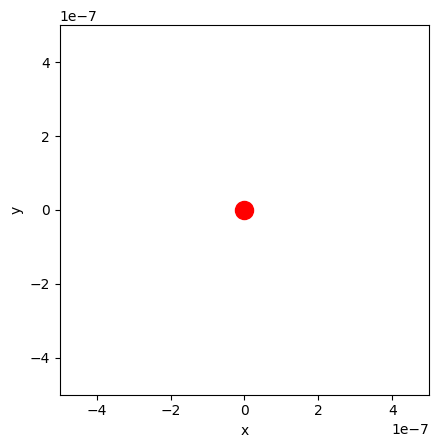

In [24]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_aspect('equal')
dot, = ax.plot([], [], 'ro', ms=13);

def init():
    dot.set_data([], [])
    return dot,

def update(frame):
    take_time_step(particles)
    dot.set_data([p.r[0] for p in particles], [p.r[1] for p in particles])
    return dot,

ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
HTML(ani.to_jshtml())

### Toevoegen animatie

Zoals gezegd: het kost veel meer rekenkracht om een animatie te maken over de tijd. Soms kan het wel helpen om te zien of de simulatie aan alle verwachtingen voldoet. 

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_aspect('equal')

# gebruik scatter voor meerdere deeltjes
scat = ax.scatter([], [], c='k', s=30)

def init():
    scat.set_offsets(np.empty((0,2)))
    return scat,

def update(frame):
    take_time_step(particles)
    coords = np.array([p.r for p in particles])
    scat.set_offsets(coords)
    return scat,

ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
plt.close(fig)
HTML(ani.to_jshtml())

### Controle code

Om te controleren of onze code werkt passen we nu de code aan.

```{exercise}
Voeg aan de simulatie een regel toe die voor elke tijdstap bepaalt wat de totale kinetische energie is voor alle deeltjes en neem deze waarde op in een array die bij elke tijdstap met één element groeit in lengte. Maak een plot van de totale kinetische energie als functie van de tijd gedurende een simulatie van 100 tijdstappen.
```

```{exercise}
:label: ex-recap-6

Maak een plot van de totale kinetische energie als functie van de tijd gedurende een simulatie van 100 tijdstappen.
```

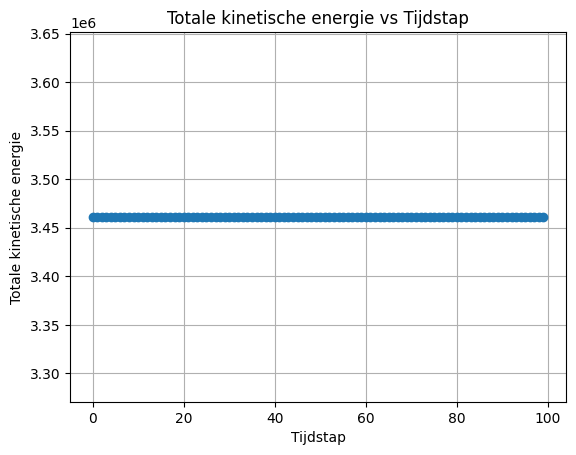

In [21]:
#7
# Lijst om totale kinetische energie per tijdstap op te slaan
total_energy = []

# Deeltjes aanmaken
particles = []
create_particles(particles)

# Simulatie uitvoeren
for i in range(100):
    take_time_step(particles)
    # Totale kinetische energie berekenen
    total_energy.append(sum(p.kin_energy for p in particles))

# Plotten van totale kinetische energie
plt.figure()
plt.plot(total_energy, marker='o')
plt.xlabel("Tijdstap")
plt.ylabel("Totale kinetische energie")
plt.title("Totale kinetische energie vs Tijdstap")
plt.grid(True)
plt.show()

```{exercise} 
:label: error_energy
Als je heel nauwkeurig naar de waarde voor de totale kinetische energie kijkt, dan varieert deze toch. Zoom hiervoor goed in op de as voor de energie. Op welke energieschaal gebeurt dit en is de oorzaak?
```

```{solution} error_energy
#9 # --- error_energy ---
# Als je goed inzoomt op de plot van de totale kinetische energie, zie je kleine variaties.
# De variatie gebeurt typisch op een schaal van ~0.1% van de totale energie.
# Oorzaak:
# - Numerieke afrondingsfouten bij de berekening van nieuwe snelheden na botsingen
# - Discrete tijdstap (DT) zorgt ervoor dat botsingen niet exact continu worden berekend
# - Samen leidt dit tot kleine fluctuaties in de totale kinetische energie
```

```{exercise}
:label: more_error
Noem nog een andere grootheid die behouden moet zijn. Geef ook van deze grootheid een plot van de waarde gedurende 100 tijdstappen. Zoom ook hier goed in. Is hier een variatie en zo ja, waardoor?
```



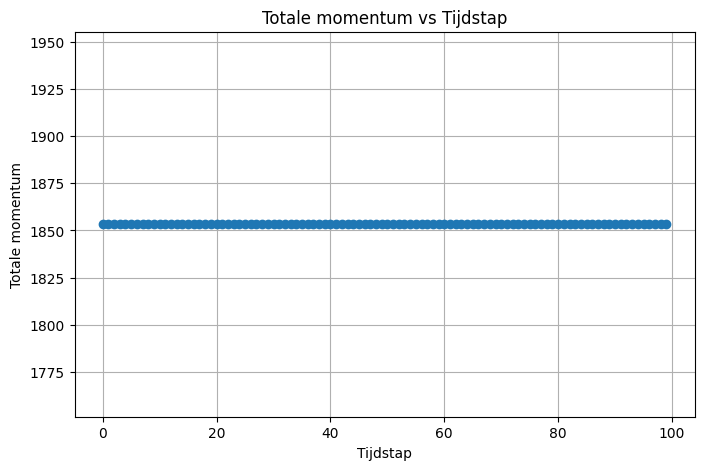

In [22]:
#10 
# Een andere grootheid die behouden moet blijven is het totale momentum van het systeem.
# Dit geldt omdat we alleen elastische botsingen uitvoeren en er geen externe krachten zijn.
# Kleine variaties kunnen optreden door:
# - Numerieke afrondingsfouten bij berekening van nieuwe snelheden
# - Discrete tijdstap (DT), waardoor botsingen niet exact continu worden berekend

# Code om totale momentum per tijdstap te berekenen en te plotten
total_momentum = []

particles = []
create_particles(particles)

for i in range(100):
    take_time_step(particles)
    # Totale momentum vector optellen (2D)
    P_tot = np.sum([p.momentum for p in particles], axis=0)
    total_momentum.append(np.linalg.norm(P_tot))  # grootte van het momentum vector

# Plot van totale momentum
plt.figure(figsize=(8,5))
plt.plot(total_momentum, marker='o')
plt.xlabel("Tijdstap")
plt.ylabel("Totale momentum")
plt.title("Totale momentum vs Tijdstap")
plt.grid(True)
plt.show()

In [23]:
#11
# De functie handle_collisions doet het volgende:
# 1. Bepaalt het aantal deeltjes in de lijst 'particles'.
# 2. Loopt over alle paren van deeltjes (i,j) waarbij j>i. 
#    Hierdoor wordt elk paar precies één keer gecontroleerd (geen dubbele botsing).
# 3. Controleert met collide_detection of de twee deeltjes elkaar overlappen.
# 4. Als dat zo is, wordt particle_collision aangeroepen om de snelheden aan te passen volgens een elastische botsing.
#
# Belangrijk:
# - Als drie deeltjes tegelijk zouden botsen, behandelt de code ze paargewijs per tijdstap.
# - Dit betekent dat in een tijdstap nooit exact drie-deeltjes-botsing wordt berekend, alleen paren.
# - Dit is acceptabel bij veel deeltjes omdat triple-botsingen zeldzaam zijn en de meeste interacties pairwise plaatsvinden.

particles = []

# Deeltje 0 (links)
particles.append(ParticleClass(m=1.0, v=[1, 0], r=[-1, 0], R=0.1))
# Deeltje 1 (rechts)
particles.append(ParticleClass(m=1.0, v=[-1, 0], r=[1, 0], R=0.1))
# Deeltje 2 (midden, stilstaand)
particles.append(ParticleClass(m=1.0, v=[0, 0], r=[0, 0], R=0.1))

# Functie om botsingen te volgen
collision_count = []

for t in range(5):  # een paar tijdstappen
    handle_collisions(particles)
    # tel het aantal botsingen deze stap
    count = 0
    for i in range(len(particles)):
        for j in range(i+1, len(particles)):
            if collide_detection(particles[i], particles[j]):
                count += 1
    collision_count.append(count)
    # update posities
    for p in particles:
        p.update_position()

print("Aantal botsingen per tijdstap:", collision_count)

Aantal botsingen per tijdstap: [0, 0, 0, 0, 0]


```{exercise}
Laat je werk aftekenen door een TA
```